

# Diffusion
The diffusion equation can be used to represent a variety of natural and environmental processes. It was introduced by Fourier in 1822 to calculate the distribution of the temperature in materials and has later been applied by Fick to material science. The mathematical expression that we will derive can be used to model, e.g., heat transfer in the earth's crust, soil evolution, transport of contaminants in an aquifer or in the atmosphere, erosion of mountain ranges, the evolution of glaciers, and many other phenomena. But before describing the equation directly, we will investigate what diffusion actually means.

Note: The lecture notes on diffusion are partly based on Dr. Frédéric Herman's course on geophysical processes. 

Author: Dr. Benjamin Campforts

![diffusion](./medias/diffusion.png)
## What is diffusion?


![diffusion_t0](./medias/Diff_Fig1.png)

**Figure 1**: Diffusion is the movement of molecules from high to low concentrations due to random processes. Here, $C$ represents the concentration, $X$ is the horizontal distance and $q$ is the net particle flow.

Due to diffusion, the particles move from the black zone to the grey zone. This can be explained by the fact that each particle can move at any moment in any direction, over a given distance. In one dimension, a particle can move to the left or to the right with equal probability, and this as well in the gray region as the black region. However, at the transition from the black zone to the grey zone, the probability of seeing particles move from left to right is much larger than the opposite, because there are many more black particles. This causes a particle transfer that depends on the difference of concentration $\Delta C$ and the distance that the particle must travel $\Delta x$, where is the difference of concentration in a transition zone of length $\Delta X$ . Therefore, we can see that the flow of particles (i.e. the number of particles passing through per unit surface and time (in 2D, mol m<sup>-1</sup> s<sup>-1</sup>) will depend on the concentration gradient. Over time, the concentration changes as illustrated in Figure 2.

![diffusion_t1](./medias/Diff_Fig2.png)

**Figure 2**: Concentration changes over time due to diffusion.

## Diffusion equation
The example above shows that changes in particle distribution depends on the concentration difference $\Delta C$ and the distance the particle must travel $\Delta x$, where is the difference in concentration in the transition zone of length $\Delta X$ (Figure 2).

From these observations, we can thus conclude that particle flow, i.e. the number of particles passing through the side of an infinitesimal block per unit of time (mol m<sup>-1</sup> s<sup>-1</sup>), will depend on the concentration gradient (Figure 2).


We can therefore say that the flux $q$, is defined by:

$$
q = -D \frac{\Delta C}{\Delta x} \tag{1}
$$

If we consider mass conservation, we are able to quantify the changes in concentration $\Delta C$ over a unit of time $t$, defined by the equation below (it's the heat equation!):

$$
\frac{\partial C}{\partial t} = D \frac{\partial^2 C}{\partial x^2} \tag{2}
$$

which depends only on the curvature (i.e. the second derivative) of the concentration and the diffusion constant. Therefore, it is sufficient to know the diffusion coefficient $D$ (which can be measured) and to measure the curvature to estimate the change in concentration over time.

[csdms-diffusion]: https://github.com/csdms/ivy/blob/main/lessons/python/diffusion.ipynb
> **Note:** For the detailed numerical solution of (2), see the [CSDMS Ivy diffusion lesson][csdms-diffusion].

Please run cell below, this is a function that solves the 1D diffusion equation. It also calculates a stable time step $\Delta t$ to run the solution based on grid spacing $\Delta x$ and diffusivity $D$. The [Von Neumann stability analysis](https://en.wikipedia.org/wiki/Von_Neumann_stability_analysis) prescribes that $\Delta t$ must be smaller than $\frac{\Delta X^2}{2D}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def diffusion_solver(z, dx=1.0, diffusivity=1.0):
    
    dt = dx **2 / (2*D)
    print(f'dt is {dt}')
    
    for t in range(0, run_duration+1):
        q = -D * np.diff(z) / dx
        z[1:-1] = z[1:-1] - dt * np.diff(q) / dx
    return z


## Hillslope diffusion

![creep](./medias/creep.png)

Experimental work (see Hillslopes session by Dr. Roda Boluda and Dr. Campforts) has shown that soil is transported down hillslopes through diffusive processes. In the following, we will apply the diffusion equation to tackle some questions related to hillslope transport.

Note that now, instead of changes in concentration of a fluid $\Delta C$, we are referring to changes in topographic elevation $\Delta z$. On soil-mantled slopes that aren't too steep, the rate of soil flow downhill, $q$, depends on how steep the hill is. We can write this mathematically as a **flux law** for soil:


$$
q = -D \frac{\Delta z}{\Delta x} \tag{3}
$$

where $z$ is the height of the land, and $x$ is distance from the hill top. The symbol $q$ represents the volume of soil flow per year per meter in the cross-slope direction. The factor $K_c$ ($c$ for "creep") has units of square meters per year, and has been estimated in the field ranging from $10^{-4}$ to $10^{-2}$, depending on the climate, vegetation, and soil type. The minus sign indicates that soil flows downhill, not uphill.

Where soil creep is the only major process shaping the land, we can also write a mass conservation equation that tells us how fast the land height, $z$, is rising or falling at a given point:

$$
\frac{\partial z}{\partial t} = - \frac{\partial q}{\partial x} \tag{4}
$$

Combining (3) and (4): 

$$\boxed{\frac{\partial z}{\partial t} = K_c \frac{\partial^2 z}{\partial x^2}}$$

This has exactly the form of a 1D diffusion equation!
We will revisit this and built more code from skratch for it in a later lecture.

## Exercise 1: Normal fault

![normal-fault](./medias/fault_scarp.png)

Let's start by simulating the evolution of topography along a normal fault. Create a 1D hillslope of 100 m with a footwall from 0 to 50 m (at the left side of the domain) sitting at 25 m above sea level (0 m) and a hanging wall between 50 and 100 m (at the right) sitting at sea level. Assume spatial steps (dx) of 0.1 m. Plot the resulting initial topography.

Let's go step by step: 
1. What libraries should we import? 
2. What is our spatial domain? 
3. How many nodes do we have? 
4. How do we add topographic elevation $z$? 
5. How do we plot this topographic profile in a graph? 

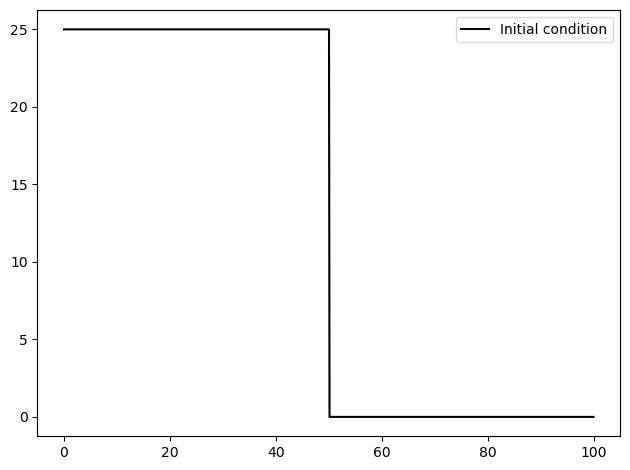

In [2]:
# numerical properties
D = 0.01
L = 100
dx = 0.1
x = np.arange(start=0, stop=L, step=dx)
nx = len(x)
run_duration = 300

# initial condition
z = np.zeros_like(x)
z1 = 25
z2 = 0

z[x <= 50] = z1
z[x > 50] = z2

z_ini = np.array(z)

# Plot the initial elevation
plt.figure()
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.legend()
plt.tight_layout()
plt.show()

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

# numerical properties
D = 0.01
L = 100
dx = 0.1
x = np.arange(start=0, stop=L, step=dx)
nx = len(x)
run_duration = 300

# initial condition
z = np.zeros_like(x)
z1 = 25
z2 = 0

z[x <= 50] = z1
z[x > 50] = z2

z_ini = np.array(z)

# Plot the initial elevation
plt.figure()
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.legend()
plt.tight_layout()
plt.show()

```
</details>

In a next step, we will evolve this landscape feature assuming diffusive hillslope processes. Run the solution for 300, 500, 1000 and 10000 years. Use a diffusion constant of 0.1 $m^2/yr$ . Plot the resulting elevation and add the initial topography to the plots. Describe what you see. 

Again, let's go step by step:
1. How many time scenarios do we have? Write it down.
2. What is our diffusivity? 
3. How do we plot the evolution of this profile in one graph?

dt is 0.5000000000000001


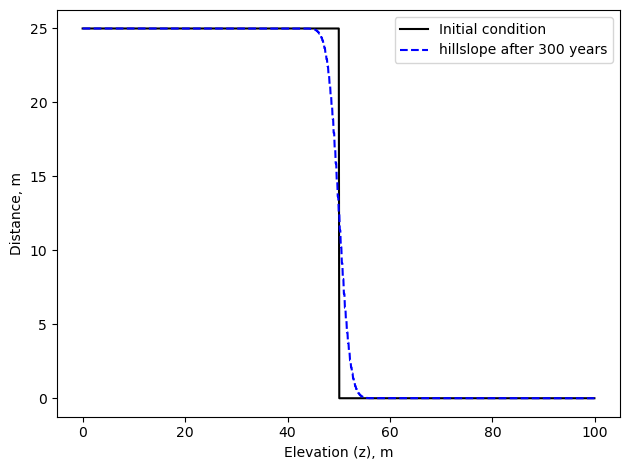

In [3]:
z = diffusion_solver(z, dx, D)
z_300 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend()
plt.tight_layout()
plt.show()

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

z = diffusion_solver(z, dx, D)
z_300 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend()
plt.tight_layout()
plt.show()

```
</details>

dt is 0.5000000000000001


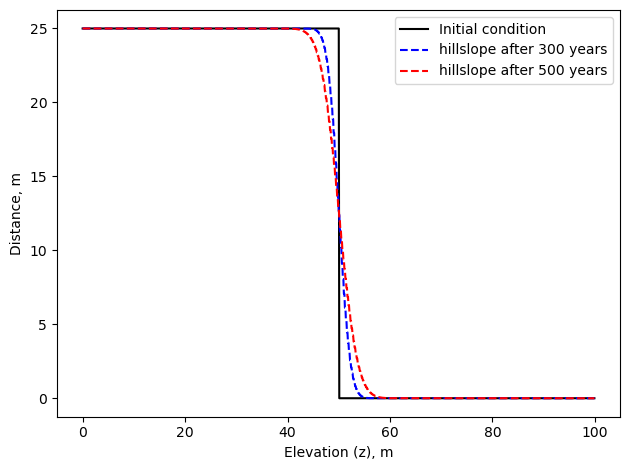

In [4]:
# 500 yrs

run_duration = 500
z= diffusion_solver(z, dx, D)
z_500 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.plot(x, z_500, '--r', label ='hillslope after 500 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend()
plt.tight_layout()
plt.show()

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

run_duration = 500
z= diffusion_solver(z, dx, D)
z_500 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.plot(x, z_500, '--r', label ='hillslope after 500 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend()
plt.tight_layout()
plt.show()

```
</details>

dt is 0.5000000000000001


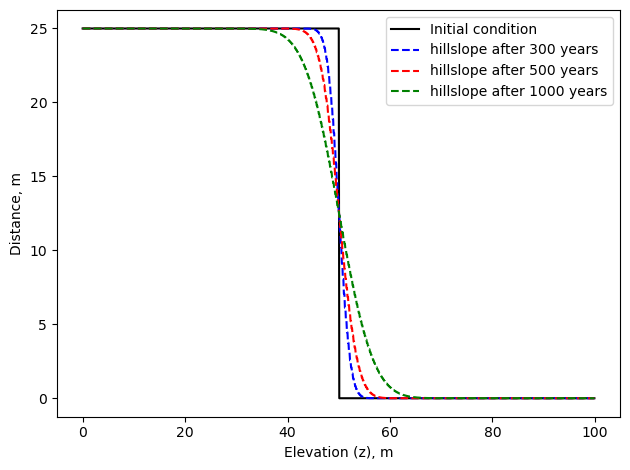

In [7]:
# 1000 yrs

run_duration = 1000
z= diffusion_solver(z, dx, D)
z_1000 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.plot(x, z_500, '--r', label ='hillslope after 500 years')
plt.plot(x, z, '--g', label ='hillslope after 1000 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

run_duration = 1000
z= diffusion_solver(z, dx, D)
z_1000 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.plot(x, z_500, '--r', label ='hillslope after 500 years')
plt.plot(x, z, '--g', label ='hillslope after 1000 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

```
</details>

dt is 0.5000000000000001


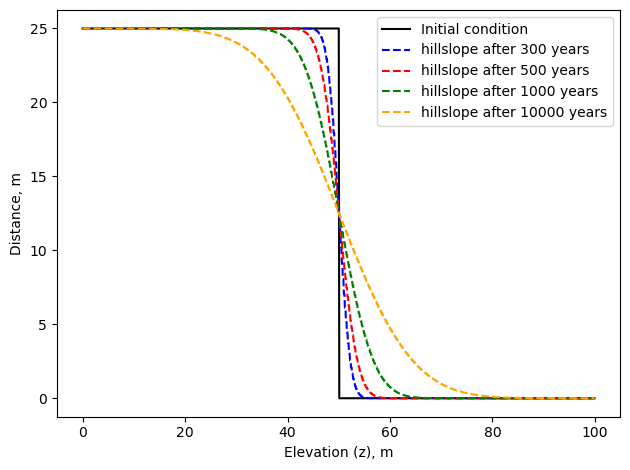

In [8]:
# 10000 yrs

run_duration = 10000
z= diffusion_solver(z, dx, D)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.plot(x, z_500, '--r', label ='hillslope after 500 years')
plt.plot(x, z_1000, '--g', label ='hillslope after 1000 years')
plt.plot(x, z, '--',color='orange' , label ='hillslope after 10000 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## INCLUDE THIS FIGURE IN THE REPORT ##

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

run_duration = 1e4
z= diffusion_solver(z, dx, D)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x,z_300, '--b', label ='hillslope after 300 years')
plt.plot(x, z_500, '--r', label ='hillslope after 500 years')
plt.plot(x, z_1000, '--g', label ='hillslope after 1000 years')
plt.plot(x, z, '--',color='orange' , label ='hillslope after 10000 years')
plt.xlabel('Elevation (z), m')
plt.ylabel('Distance, m')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

```
</details>

## Exercise 2: Hillslope Evolution and response to river incision

Now let's consider another common type of hillslope profile to see how it responds to fluvial incision. First, can someone remember one of the main drivers of increases in fluvial incision? 

For this exercise we will use a different function. Please run cell above:

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def evolve_elevation(elevation, incision_rate, D, dx, dt, run_duration):
    
    timesteps = run_duration//dt
    
    for t in range(timesteps):
        drop_per_step = incision_rate * dt
        elevation[0] -= drop_per_step
        elevation[-1] -= drop_per_step
        soil_flux = -D * np.diff(elevation) / dx
        elev_rate_of_change = np.diff(soil_flux) / dx
        elevation[1:-1] -= dt * elev_rate_of_change

    return elevation

Let's set the parameters and plot our initial hillslope profile. Let's imagine that the boundaries of this hillslope are rivers that are incising at a certain rate. You will build a 10m profile, with a spacing $dx$ of 1 meter. The boundary cells will have elevation $z$ = 0, and the core cells will have elevation $z$ = 5 meters above sea level. Let's first simulate diffusion without any incision. Consider a timestep $dt$ of 10 years, diffusivity $D$ as 0.001 $m^2$/yr. Define the parameters and plot the initial profile. 

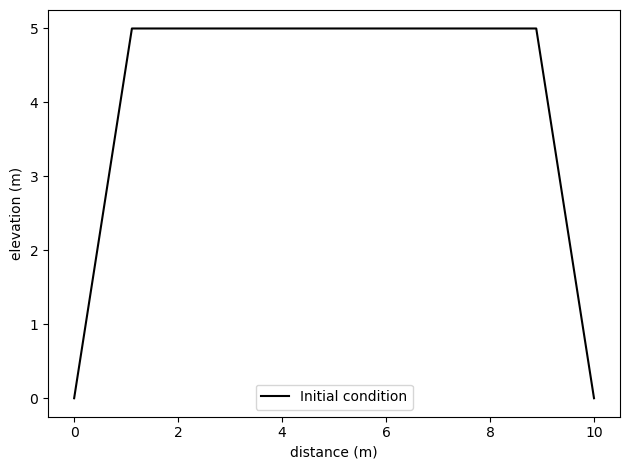

In [10]:
dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
incision_rate = 0  # m/yr

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

z_ini = np.array(z)

plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.legend()
plt.tight_layout()
plt.show()

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python
dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
incision_rate = 0  # m/yr

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

z_ini = np.array(z)

plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.legend()
plt.tight_layout()
plt.show()

```
</details>

Now run the evolve_elevation function for 50 years using the parameters you have just defined. Plot the 50 year profile together with the initial profile. 

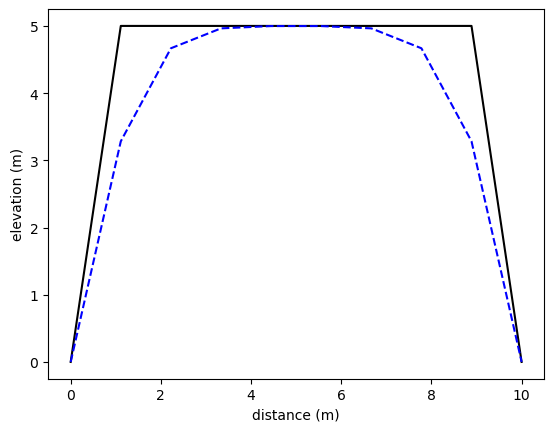

In [11]:
run_duration = 50

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_50 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x, z_50, '--b', label='after 50 yrs')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.show()


<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

run_duration = 50

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_50 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x, z_50, '--b', label='after 50 yrs')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.show()

```
</details>

Now run the simulation again for 100, 300 and 500 years. Add the profiles to your plot

In [12]:
# 100 yr
run_duration = 100

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_100 = np.array(z)

In [13]:
# 300 yr

run_duration = 300

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_300 = np.array(z)

In [14]:
# 500 yr

run_duration = 500

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)

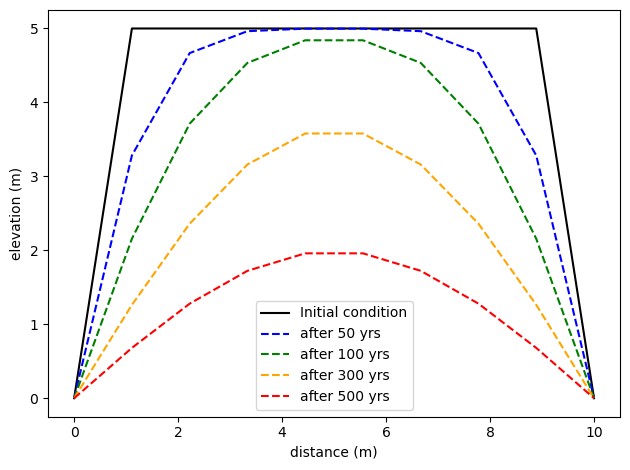

In [15]:
# final plot with all the profiles

plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x, z_50, '--b', label='after 50 yrs')
plt.plot(x, z_100, '--g', label='after 100 yrs')
plt.plot(x, z_300, '--', color='orange', label='after 300 yrs')
plt.plot(x, z, '--r', label='after 500 yrs')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.legend()
plt.tight_layout()
plt.show()

## INCLUDE THIS FIGURE IN THE REPORT ##

Now let's see how river incision will change hillslope evolution. Consider an incision rate of 0.001 m/yr. Run the same simulation again with rivers incising. 

In [16]:
dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
incision_rate = 0.001  # m/yr

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

z_ini = np.array(z)

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
incision_rate = 0.001  # m/yr

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

z_ini = np.array(z)

```
</details>

In [17]:
# run_duration = 50

run_duration = 50

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_50 = np.array(z)

run_duration = 100

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_100 = np.array(z)

run_duration = 300

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_300 = np.array(z)

run_duration = 500

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

run_duration = 50

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_50 = np.array(z)

run_duration = 100

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_100 = np.array(z)

run_duration = 300

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_300 = np.array(z)

run_duration = 500

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
```
</details>

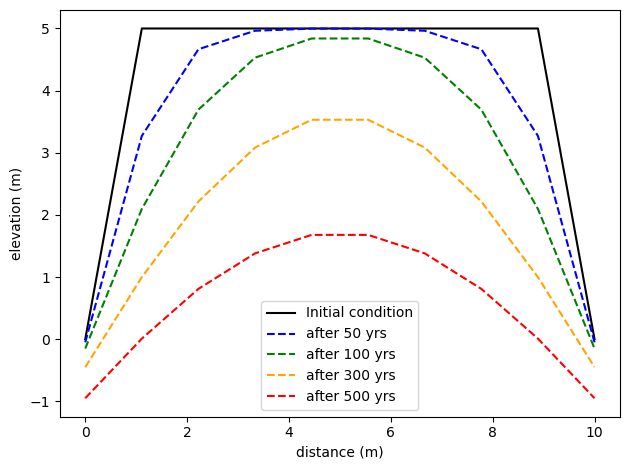

In [18]:
# plot all the profiles in one plot 

plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x, z_50, '--b', label='after 50 yrs')
plt.plot(x, z_100, '--g', label='after 100 yrs')
plt.plot(x, z_300, '--', color='orange', label='after 300 yrs')
plt.plot(x, z, '--r', label='after 500 yrs')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.legend()
plt.tight_layout()
plt.show()

## INCLUDE THIS FIGURE IN THE REPORT ##

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x, z_50, '--b', label='after 50 yrs')
plt.plot(x, z_100, '--g', label='after 100 yrs')
plt.plot(x, z_300, '--', color='orange', label='after 300 yrs')
plt.plot(x, z, '--r', label='after 500 yrs')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.legend()
plt.tight_layout()
plt.show()

```
</details>

Finally, let's simulate how a hillslope evolve for 200 years using 3 river incision scenarios: 1) No incision, 2) incision = 0.001 m/yr, 3) incision = 0.01 m/yr. Plot all the profiles in one figure. 

In [19]:
dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
run_duration = 200

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

z_ini = np.array(z)

incision_rate = 0  # m/yr

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_incision0 = np.array(z)

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
run_duration = 200

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

z_ini = np.array(z)

incision_rate = 0  # m/yr

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_incision0 = np.array(z)

```
</details>

In [20]:
dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
run_duration = 200

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev


incision_rate = 0.001  # m/yr

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_incision1 = np.array(z)


<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
run_duration = 200

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev


incision_rate = 0.001  # m/yr

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_incision1 = np.array(z)

```
</details>

In [21]:
dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
run_duration = 200

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

incision_rate = 0.01  # m/yr

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_incision2 = np.array(z)



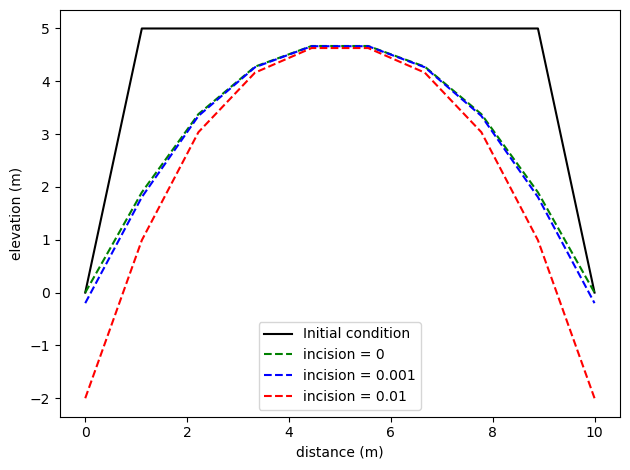

In [23]:
# plot the profiles

plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x, z_incision0, '--g', label='incision = 0')
plt.plot(x, z_incision1, '--b', label='incision = 0.001')
plt.plot(x, z_incision2, '--r', label='incision = 0.01')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.legend()
plt.tight_layout()
plt.show()

## INCLUDE THIS FIGURE IN THE REPORT ##

<details>
    <summary>👉 <b>click to see solution</b></summary>

```python

dt = 10  # length of timestep (yr)
L = 10  # length of domain (m)
dx = 1  # distance between nodes (m)
initial_elev = 5  # elevation at internal nodes (m)
D = 1e-02  # diffusion coefficient (m2/yr)
run_duration = 200

num_nodes = int(L / dx)

x = np.linspace(0, L, int(num_nodes))
z = np.zeros_like(x, dtype=float)
z[1:-1] = initial_elev

incision_rate = 0.01  # m/yr

z = evolve_elevation(z, incision_rate, D, dx, dt, run_duration)
z_incision2 = np.array(z)
plt.plot(x,z_ini, 'black', label= 'Initial condition')
plt.plot(x, z_incision0, '--b', label='incision = 0')
plt.plot(x, z_incision1, '--b', label='incision = 0.001')
plt.plot(x, z_incision2, '--r', label='incision = 0.01')
plt.xlabel("distance (m)")
plt.ylabel("elevation (m)")
plt.legend()
plt.tight_layout()
plt.show()

```
</details>